In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

import tenso

print("Python:", sys.executable)
print("TENSO:", tenso.__file__)

Python: /user/jkarin/.conda/envs/tenso/bin/python
TENSO: /user/jkarin/pytenso/pytenso/src/tenso/__init__.py


In [2]:
from tenso.prototypes.heom import system_multibath
from tenso.prototypes.bath import gen_bcf

In [3]:
from pathlib import Path
import pandas as pd

data_file = Path("../data/o2_cas64_extracted_parameters.csv")

params_df = pd.read_csv(data_file)
params_df

,parameter,value
0,equilibrium_bond_length_angstrom,1.183009
1,triplet_force_constant_N_per_m,1503.444337
2,harmonic_frequency_cm-1,1786.023362
3,singlet_triplet_gap_at_Re_eV,0.812857
4,gap_slope_eV_per_angstrom,-1.236993


In [4]:
pyscf_params = dict(zip(params_df["parameter"], params_df["value"]))

EV_TO_CM1 = 8065.544005
EV_TO_J = 1.602176634e-19
ANGSTROM_TO_M = 1.0e-10

gap_ev = pyscf_params["singlet_triplet_gap_at_Re_eV"]
mode_frequency_cm1 = pyscf_params["harmonic_frequency_cm-1"]
gap_slope_ev_per_angstrom = pyscf_params["gap_slope_eV_per_angstrom"]
force_constant_n_per_m = pyscf_params["triplet_force_constant_N_per_m"]

gap_cm1 = gap_ev * EV_TO_CM1

force_constant_ev_per_angstrom2 = (
    force_constant_n_per_m
    * ANGSTROM_TO_M**2
    / EV_TO_J
)

reorganization_energy_ev = (
    gap_slope_ev_per_angstrom**2
    / (2.0 * force_constant_ev_per_angstrom2)
)

reorganization_energy_cm1 = (
    reorganization_energy_ev * EV_TO_CM1
)

huang_rhys_factor = (
    reorganization_energy_cm1 / mode_frequency_cm1
)

print(f"Electronic gap:        {gap_cm1:.2f} cm^-1")
print(f"O-O frequency:         {mode_frequency_cm1:.2f} cm^-1")
print(f"Reorganization energy: {reorganization_energy_cm1:.2f} cm^-1")
print(f"Huang-Rhys factor:     {huang_rhys_factor:.5f}")

Electronic gap:        6556.14 cm^-1
O-O frequency:         1786.02 cm^-1
Reorganization energy: 65.76 cm^-1
Huang-Rhys factor:     0.03682


In [5]:
sys_ham = np.array(
    [
        [0.0, 0.0],
        [0.0, gap_cm1],
    ],
    dtype=complex,
)

sys_op = np.array(
    [
        [-0.5, 0.0],
        [0.0, 0.5],
    ],
    dtype=complex,
)

sys_ops = [sys_op]

init_rdo = 0.5 * np.array(
    [
        [1.0, 1.0],
        [1.0, 1.0],
    ],
    dtype=complex,
)

print("Hamiltonian:")
print(sys_ham)

print("\nSystem-bath operator:")
print(sys_op)

print("\nInitial density matrix:")
print(init_rdo)

Hamiltonian:
[[   0.        +0.j    0.        +0.j]
 [   0.        +0.j 6556.13690332+0.j]]

System-bath operator:
[[-0.5+0.j  0. +0.j]
 [ 0. +0.j  0.5+0.j]]

Initial density matrix:
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]


In [6]:
temperature = 300.0
brownian_width_cm1 = 50.0

o2_bath = gen_bcf(
    include_drude=False,
    include_brownian=True,
    freq_b=[mode_frequency_cm1],
    re_b=[reorganization_energy_cm1],
    width_b=[brownian_width_cm1],
    include_discrete=False,
    temperature=temperature,
    decomposition_method="Pade",
    n_ltc=1,
)

bath_correlations = [o2_bath]

print(o2_bath)

Correlation ( c | c* | z ) x3 :
+1.1756e-01+5.3213e-06j | +2.1760e-05+5.3213e-06j | +1.00e+00+0.00e+00j
+2.1760e-05-5.3213e-06j | +1.1756e-01-5.3213e-06j | +1.00e+00+0.00e+00j
-2.1025e-03+0.0000e+00j | -2.1025e-03-0.0000e+00j | +1.00e+00+0.00e+00j
Derivatives:
  [0, 0] : -5.0000e-02-1.7860e+00j
  [1, 1] : -5.0000e-02+1.7860e+00j
  [2, 2] : -1.6151e+00+0.0000e+00j
No Lindblad rate.


In [7]:
import inspect
import tenso.prototypes.heom as heom_module

print(inspect.getsourcefile(heom_module.system_multibath))
print()
print(inspect.getsource(heom_module.system_multibath))


/user/jkarin/pytenso/pytenso/src/tenso/prototypes/heom.py

def system_multibath(
    fname: str,
    # System
    init_rdo: MatList,
    sys_ham: MatList,
    sys_ops: list[MatList],
    # Bath
    bath_correlations: list[Correlation],
    # Time-dependent field
    td_f: Callable[[float], float] | None = None,
    td_op: MatList | None = None,
    # other settings
    **kwargs,
) -> Generator[float, None, None]:
    """Spin-Boson model using HEOM with tensor network allowing multiple bath correlation functions.

    Parameters:
    -----------
    :type fname: str
    :param fname: The output file name.

    :type init_rdo: MatList
    :param init_rdo: The initial reduced density operator.

    :type h: MatList
    :param h: The system Hamiltonian.

    :type op: MatList
    :param op: The system operator in the system-bath interaction hamiltonian.

    :type bath_correlation: :class:`Correlation`
    :param bath_correlation: The bath correlation function for HEOM.

    :type td_f: Ca

In [8]:
from pathlib import Path
import tenso

tenso_root = Path(tenso.__file__).resolve().parent

matches = list(tenso_root.rglob("default_parameters.py"))

print("Matches:")
for path in matches:
    print(path)

Matches:
/user/jkarin/pytenso/pytenso/src/tenso/prototypes/default_parameters.py


In [9]:
default_file = matches[0]

print(default_file.read_text())

# coding: utf-8
"""Default parameters for the prototypes in the package.
"""

from typing import Literal
from tenso.libs.quantity import Quantity as __

__all__ = [
    "default_units",
    "default_kwargs",
    "default_extension",
    "get_default_kwargs",
]

default_extension = {
    'input': '.json',
    'output': '.dat.log',
    'debug': '.debug.log',
    'checkpoint': '.pt',
}

default_units = {
    "inverse_temperature": "/K",
    "time": "fs",
    "energy": "/cm",
    "unital_energy": 1000.0,
}

default_kwargs = {
    # For bath correlation function
    "bcf.decomposition_method": "Pade",
    "bcf.n_ltc": 3,
    "bcf.include_lindblad": False,
    "bcf.use_ht_function": False,
    "bcf.use_cross": False,
    "bcf.temperature": 300,
    # For HEOM
    "heom.dim": 5,
    "heom.use_dvr": False,
    "heom.dvr_type": "sine",
    "heom.dvr_length": 32,
    "heom.metric": "re",
    # For QLE
    "qle.dim": 5,
    "qle.use_dvr": False,
    "qle.dvr_type": "sine",
    "qle.dvr_length": 3

In [10]:
from pathlib import Path

output_prefix = Path("../data/o2_tenso_short_test")
output_prefix.parent.mkdir(parents=True, exist_ok=True)

simulation = system_multibath(
    fname=str(output_prefix),
    init_rdo=init_rdo.tolist(),
    sys_ham=sys_ham.tolist(),
    sys_ops=[sys_op.tolist()],
    bath_correlations=bath_correlations,

    # Short test settings
    start_time=0.0,
    end_time=20.0,
    step_time=0.5,

    # Reduced hierarchy for the initial test
    dim=3,

    # Propagation settings
    ode_method="dopri5",
    ode_rtol=1.0e-5,
    ode_atol=1.0e-7,

    # Tensor-network settings
    rank=3,
    frame_method="tree2",

    save_checkpoint_to_file=False,
)

print("Simulation generator created.")

Simulation generator created.


In [11]:
times = []

for current_time in simulation:
    times.append(current_time)
    print(f"t = {current_time:.2f} fs")

print("Propagation complete.")
print(f"Number of reported times: {len(times)}")

{'auxiliary_ps_method': 'ps2', 'auxiliary_step_time': None, 'cache_svd_info': True, 'dim': 3, 'dvr_length': 32, 'dvr_type': 'sine', 'end_time': 20.0, 'frame_method': 'tree2', 'load_checkpoint_from_file': False, 'max_auxiliary_rank': 32, 'max_auxiliary_steps': None, 'metric': 're', 'ode_atol': 1e-07, 'ode_method': 'dopri5', 'ode_rtol': 1e-05, 'ps2_atol': 1e-07, 'ps2_ratio': 2.0, 'ps_method': 'vmf', 'rank': 3, 'renormalize': False, 'save_checkpoint_to_file': False, 'start_time': 0.0, 'step_time': 0.5, 'stepwise_method': 'mix', 'use_dvr': False, 'visualize_frame': False, 'vmf_atol': 1e-07, 'vmf_reg_method': 'extend', 'vmf_reg_type': 'ip'}


TypeError: can't multiply sequence by non-int of type 'float'

In [12]:
simulation = system_multibath(
    fname=str(output_prefix),
    init_rdo=init_rdo,
    sys_ham=sys_ham,
    sys_ops=sys_ops,
    bath_correlations=bath_correlations,

    start_time=0.0,
    end_time=20.0,
    step_time=0.5,

    dim=3,

    ode_method="dopri5",
    ode_rtol=1.0e-5,
    ode_atol=1.0e-7,

    rank=3,
    frame_method="tree2",

    save_checkpoint_to_file=False,
)

print("Simulation generator created.")

Simulation generator created.


In [13]:
times = []

for current_time in simulation:
    times.append(current_time)
    print(f"t = {current_time:.2f} fs")

print("Propagation complete.")
print(f"Number of reported times: {len(times)}")

{'auxiliary_ps_method': 'ps2', 'auxiliary_step_time': None, 'cache_svd_info': True, 'dim': 3, 'dvr_length': 32, 'dvr_type': 'sine', 'end_time': 20.0, 'frame_method': 'tree2', 'load_checkpoint_from_file': False, 'max_auxiliary_rank': 32, 'max_auxiliary_steps': None, 'metric': 're', 'ode_atol': 1e-07, 'ode_method': 'dopri5', 'ode_rtol': 1e-05, 'ps2_atol': 1e-07, 'ps2_ratio': 2.0, 'ps_method': 'vmf', 'rank': 3, 'renormalize': False, 'save_checkpoint_to_file': False, 'start_time': 0.0, 'step_time': 0.5, 'stepwise_method': 'mix', 'use_dvr': False, 'visualize_frame': False, 'vmf_atol': 1e-07, 'vmf_reg_method': 'extend', 'vmf_reg_type': 'ip'}
For k=0: s:0.05879211 | e:0.05877035 | a:0.00000532 | f:-0.24247083 | f^2:0.05879211
For k=1: s:0.05879211 | e:-0.05877035 | a:-0.00000532 | f:0.24247083 | f^2:0.05879211
For k=2: s:-0.00210253 | e:0.00000000 | a:0.00000000 | f:0.04585331 | f^2:0.00210253
t = 0.00 fs
t = 0.50 fs
t = 1.00 fs
t = 1.50 fs
t = 2.00 fs
t = 2.50 fs
t = 3.00 fs
t = 3.50 fs
t = 

In [14]:
from pathlib import Path

files = list(Path("../data").glob("o2_tenso_short_test*"))
files

[PosixPath('../data/o2_tenso_short_test.dat.log'),
 PosixPath('../data/o2_tenso_short_test.debug.log')]

In [15]:
output_file = Path("../data/o2_tenso_short_test.dat.log")

print(output_file.exists())
print(output_file.read_text().splitlines()[:15])

True
['# time rdo00 rdo01 rdo10 rdo11', '0.0 0.50000000+0.00000000j 0.50000000+0.00000000j 0.50000000+0.00000000j 0.50000000+0.00000000j', '0.5 0.49999981+0.00000000j 0.40746533+0.28934427j 0.40746533-0.28934427j 0.50000031-0.00000000j', '1.0 0.49999981+0.00000000j 0.16444940+0.47111952j 0.16444940-0.47111952j 0.50000031+0.00000000j', '1.5 0.49999981-0.00000000j -0.13834544+0.47815531j -0.13834544-0.47815531j 0.50000031-0.00000000j', '2.0 0.49999981-0.00000000j -0.38833876+0.30872237j -0.38833876-0.30872237j 0.50000031+0.00000000j', '2.5000000000000004 0.49999981-0.00000000j -0.49332626+0.02676009j -0.49332626-0.02676009j 0.50000031+0.00000000j', '3.0 0.49999981-0.00000000j -0.41571729-0.26254332j -0.41571729+0.26254332j 0.50000031+0.00000000j', '3.5000000000000004 0.49999981-0.00000000j -0.18594582-0.45233309j -0.18594582+0.45233309j 0.50000031+0.00000000j', '4.0 0.49999981-0.00000000j 0.10965510-0.47374586j 0.10965510+0.47374586j 0.50000031-0.00000000j', '4.5 0.49999981-0.00000000j 0

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

output_file = Path("../data/o2_tenso_short_test.dat.log")

times = []
rdo00 = []
rdo01 = []
rdo10 = []
rdo11 = []

with output_file.open() as f:
    next(f)  # skip header

    for line in f:
        columns = line.split()

        times.append(float(columns[0]))
        rdo00.append(complex(columns[1]))
        rdo01.append(complex(columns[2]))
        rdo10.append(complex(columns[3]))
        rdo11.append(complex(columns[4]))

times = np.asarray(times)
rdo00 = np.asarray(rdo00)
rdo01 = np.asarray(rdo01)
rdo10 = np.asarray(rdo10)
rdo11 = np.asarray(rdo11)

normalized_coherence = np.abs(rdo01) / np.abs(rdo01[0])

print("Maximum trace error:",
      np.max(np.abs((rdo00 + rdo11).real - 1.0)))

print("Maximum Hermiticity error:",
      np.max(np.abs(rdo10 - np.conjugate(rdo01))))

Maximum trace error: 1.199999999368373e-07
Maximum Hermiticity error: 0.0


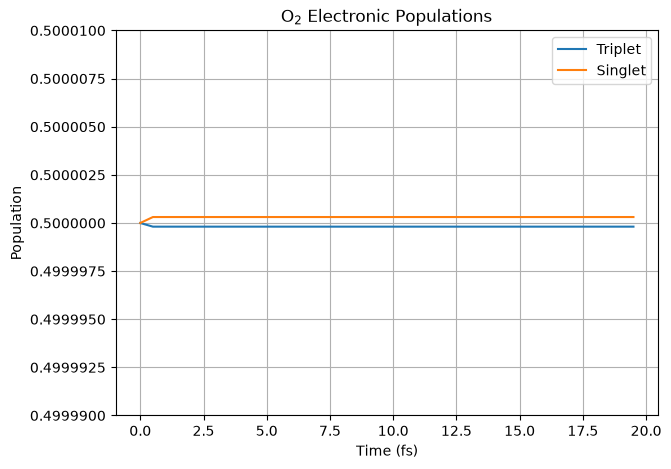

In [18]:
plt.figure(figsize=(7,5))

plt.plot(times, rdo00.real, label="Triplet")
plt.plot(times, rdo11.real, label="Singlet")

plt.xlabel("Time (fs)")
plt.ylabel("Population")
plt.title("O$_2$ Electronic Populations")

plt.ylim(0.49999,0.50001)

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.grid(True)
plt.legend()

plt.show()

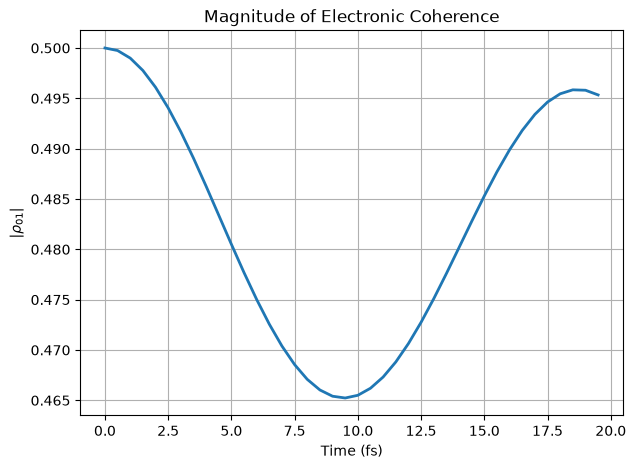

In [19]:
plt.figure(figsize=(7,5))

plt.plot(times, np.abs(rdo01), lw=2)

plt.xlabel("Time (fs)")
plt.ylabel(r"$|\rho_{01}|$")
plt.title("Magnitude of Electronic Coherence")
plt.grid(True)

plt.show()

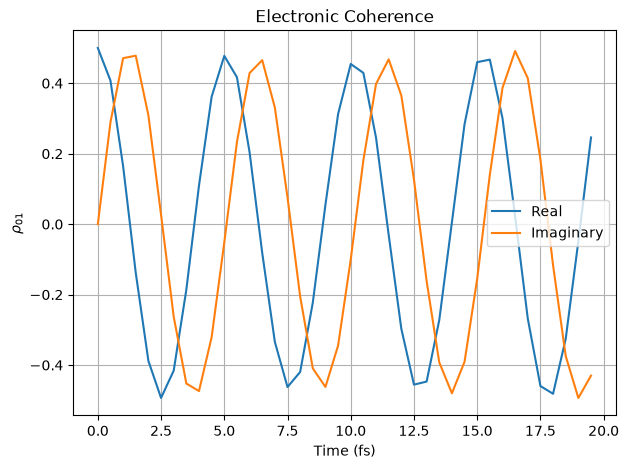

In [20]:
plt.figure(figsize=(7,5))

plt.plot(times, rdo01.real, label="Real")
plt.plot(times, rdo01.imag, label="Imaginary")

plt.xlabel("Time (fs)")
plt.ylabel(r"$\rho_{01}$")
plt.title("Electronic Coherence")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
from pathlib import Path
import numpy as np

tenso_output_dir = Path("../data/tenso_runs")
tenso_output_dir.mkdir(parents=True, exist_ok=True)


def read_tenso_output(output_file):
    """Read a TENSO reduced-density-matrix output file."""

    times = []
    rho00 = []
    rho01 = []
    rho10 = []
    rho11 = []

    with Path(output_file).open() as handle:
        next(handle)  # Skip header

        for line in handle:
            columns = line.split()

            times.append(float(columns[0]))
            rho00.append(complex(columns[1]))
            rho01.append(complex(columns[2]))
            rho10.append(complex(columns[3]))
            rho11.append(complex(columns[4]))

    return {
        "time": np.asarray(times),
        "rho00": np.asarray(rho00),
        "rho01": np.asarray(rho01),
        "rho10": np.asarray(rho10),
        "rho11": np.asarray(rho11),
    }


def run_o2_case(
    case_name,
    temperature=300.0,
    reorganization_energy=reorganization_energy_cm1,
    brownian_width=50.0,
    end_time=60.0,
    step_time=0.5,
    hierarchy_dim=3,
):
    """Run one O2 pure-dephasing calculation."""

    bath = gen_bcf(
        include_drude=False,
        include_brownian=True,
        freq_b=[mode_frequency_cm1],
        re_b=[reorganization_energy],
        width_b=[brownian_width],
        include_discrete=False,
        temperature=temperature,
        decomposition_method="Pade",
        n_ltc=1,
    )

    output_prefix = tenso_output_dir / case_name
    output_file = Path(str(output_prefix) + ".dat.log")

    # Remove an older output so we do not accidentally read stale data.
    if output_file.exists():
        output_file.unlink()

    simulation = system_multibath(
        fname=str(output_prefix),
        init_rdo=init_rdo,
        sys_ham=sys_ham,
        sys_ops=sys_ops,
        bath_correlations=[bath],
        start_time=0.0,
        end_time=end_time,
        step_time=step_time,
        dim=hierarchy_dim,
        ode_method="dopri5",
        ode_rtol=1.0e-5,
        ode_atol=1.0e-7,
        rank=3,
        frame_method="tree2",
        save_checkpoint_to_file=False,
    )

    for _ in simulation:
        pass

    if not output_file.exists():
        raise FileNotFoundError(
            f"TENSO did not create the expected file: {output_file}"
        )

    result = read_tenso_output(output_file)

    result["normalized_coherence"] = (
        np.abs(result["rho01"]) / np.abs(result["rho01"][0])
    )

    result["temperature"] = temperature
    result["reorganization_energy"] = reorganization_energy
    result["brownian_width"] = brownian_width
    result["output_file"] = output_file

    trace_error = np.max(
        np.abs((result["rho00"] + result["rho11"]).real - 1.0)
    )

    hermiticity_error = np.max(
        np.abs(result["rho10"] - np.conjugate(result["rho01"]))
    )

    print(
        f"{case_name}: "
        f"T={temperature:g} K, "
        f"lambda={reorganization_energy:.2f} cm^-1, "
        f"width={brownian_width:g} cm^-1"
    )
    print(f"  Final coherence: {result['normalized_coherence'][-1]:.6f}")
    print(f"  Maximum trace error: {trace_error:.3e}")
    print(f"  Maximum Hermiticity error: {hermiticity_error:.3e}")

    return result

In [22]:
temperature_results = {}

for temperature_value in [77.0, 150.0, 300.0]:
    case_name = f"o2_temperature_{int(temperature_value)}K"

    temperature_results[temperature_value] = run_o2_case(
        case_name=case_name,
        temperature=temperature_value,
        reorganization_energy=reorganization_energy_cm1,
        brownian_width=50.0,
        end_time=60.0,
        step_time=0.5,
        hierarchy_dim=3,
    )

{'auxiliary_ps_method': 'ps2', 'auxiliary_step_time': None, 'cache_svd_info': True, 'dim': 3, 'dvr_length': 32, 'dvr_type': 'sine', 'end_time': 60.0, 'frame_method': 'tree2', 'load_checkpoint_from_file': False, 'max_auxiliary_rank': 32, 'max_auxiliary_steps': None, 'metric': 're', 'ode_atol': 1e-07, 'ode_method': 'dopri5', 'ode_rtol': 1e-05, 'ps2_atol': 1e-07, 'ps2_ratio': 2.0, 'ps_method': 'vmf', 'rank': 3, 'renormalize': False, 'save_checkpoint_to_file': False, 'start_time': 0.0, 'step_time': 0.5, 'stepwise_method': 'mix', 'use_dvr': False, 'visualize_frame': False, 'vmf_atol': 1e-07, 'vmf_reg_method': 'extend', 'vmf_reg_type': 'ip'}
For k=0: s:0.05877035 | e:0.05877035 | a:0.00000000 | f:0.24242596 | f^2:0.05877035
For k=1: s:0.05877035 | e:-0.05877035 | a:-0.00000000 | f:0.24242596 | f^2:0.05877035
For k=2: s:-0.00041157 | e:0.00000000 | a:0.00000000 | f:0.02028712 | f^2:0.00041157
o2_temperature_77K: T=77 K, lambda=65.76 cm^-1, width=50 cm^-1
  Final coherence: 0.959110
  Maximum 

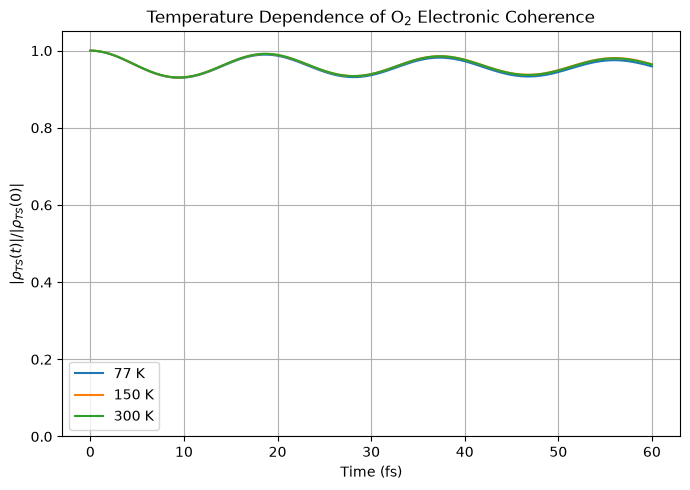

In [23]:
plt.figure(figsize=(7, 5))

for temperature_value, result in temperature_results.items():
    plt.plot(
        result["time"],
        result["normalized_coherence"],
        label=f"{temperature_value:g} K",
    )

plt.xlabel("Time (fs)")
plt.ylabel(r"$|\rho_{TS}(t)|/|\rho_{TS}(0)|$")
plt.title("Temperature Dependence of O$_2$ Electronic Coherence")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
coupling_factors = [0.25, 1.0, 2.0]
coupling_results = {}

for factor in coupling_factors:
    lambda_value = factor * reorganization_energy_cm1
    case_name = f"o2_coupling_{factor:g}x".replace(".", "p")

    coupling_results[factor] = run_o2_case(
        case_name=case_name,
        temperature=300.0,
        reorganization_energy=lambda_value,
        brownian_width=50.0,
        end_time=60.0,
        step_time=0.5,
        hierarchy_dim=3,
    )

{'auxiliary_ps_method': 'ps2', 'auxiliary_step_time': None, 'cache_svd_info': True, 'dim': 3, 'dvr_length': 32, 'dvr_type': 'sine', 'end_time': 60.0, 'frame_method': 'tree2', 'load_checkpoint_from_file': False, 'max_auxiliary_rank': 32, 'max_auxiliary_steps': None, 'metric': 're', 'ode_atol': 1e-07, 'ode_method': 'dopri5', 'ode_rtol': 1e-05, 'ps2_atol': 1e-07, 'ps2_ratio': 2.0, 'ps_method': 'vmf', 'rank': 3, 'renormalize': False, 'save_checkpoint_to_file': False, 'start_time': 0.0, 'step_time': 0.5, 'stepwise_method': 'mix', 'use_dvr': False, 'visualize_frame': False, 'vmf_atol': 1e-07, 'vmf_reg_method': 'extend', 'vmf_reg_type': 'ip'}
For k=0: s:0.01469803 | e:0.01469259 | a:0.00000133 | f:-0.12123542 | f^2:0.01469803
For k=1: s:0.01469803 | e:-0.01469259 | a:-0.00000133 | f:0.12123542 | f^2:0.01469803
For k=2: s:-0.00052563 | e:0.00000000 | a:0.00000000 | f:0.02292665 | f^2:0.00052563
o2_coupling_0p25x: T=300 K, lambda=16.44 cm^-1, width=50 cm^-1
  Final coherence: 0.992423
  Maximum

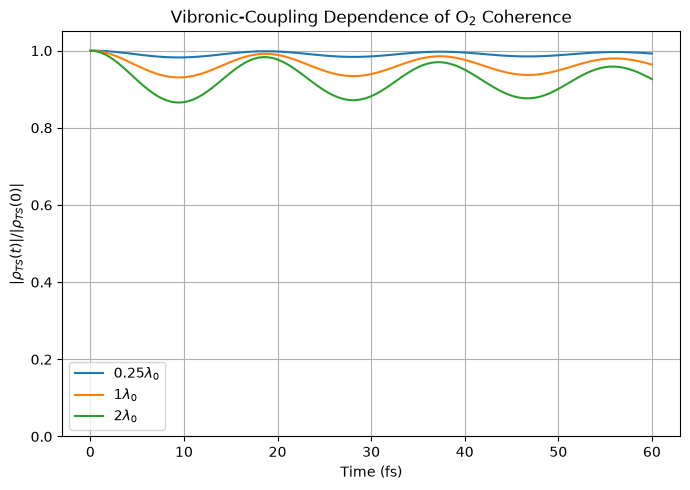

In [25]:
plt.figure(figsize=(7, 5))

for factor, result in coupling_results.items():
    plt.plot(
        result["time"],
        result["normalized_coherence"],
        label=rf"${factor:g}\lambda_0$",
    )

plt.xlabel("Time (fs)")
plt.ylabel(r"$|\rho_{TS}(t)|/|\rho_{TS}(0)|$")
plt.title("Vibronic-Coupling Dependence of O$_2$ Coherence")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
width_values = [20.0, 50.0, 100.0]
width_results = {}

for width_value in width_values:
    case_name = f"o2_width_{int(width_value)}cm1"

    width_results[width_value] = run_o2_case(
        case_name=case_name,
        temperature=300.0,
        reorganization_energy=reorganization_energy_cm1,
        brownian_width=width_value,
        end_time=60.0,
        step_time=0.5,
        hierarchy_dim=3,
    )

{'auxiliary_ps_method': 'ps2', 'auxiliary_step_time': None, 'cache_svd_info': True, 'dim': 3, 'dvr_length': 32, 'dvr_type': 'sine', 'end_time': 60.0, 'frame_method': 'tree2', 'load_checkpoint_from_file': False, 'max_auxiliary_rank': 32, 'max_auxiliary_steps': None, 'metric': 're', 'ode_atol': 1e-07, 'ode_method': 'dopri5', 'ode_rtol': 1e-05, 'ps2_atol': 1e-07, 'ps2_ratio': 2.0, 'ps_method': 'vmf', 'rank': 3, 'renormalize': False, 'save_checkpoint_to_file': False, 'start_time': 0.0, 'step_time': 0.5, 'stepwise_method': 'mix', 'use_dvr': False, 'visualize_frame': False, 'vmf_atol': 1e-07, 'vmf_reg_method': 'extend', 'vmf_reg_type': 'ip'}
For k=0: s:0.05875397 | e:0.05873169 | a:0.00000214 | f:-0.24239218 | f^2:0.05875397
For k=1: s:0.05875397 | e:-0.05873169 | a:-0.00000214 | f:0.24239218 | f^2:0.05875397
For k=2: s:-0.00084052 | e:0.00000000 | a:0.00000000 | f:0.02899169 | f^2:0.00084052
o2_width_20cm1: T=300 K, lambda=65.76 cm^-1, width=20 cm^-1
  Final coherence: 0.968987
  Maximum tr

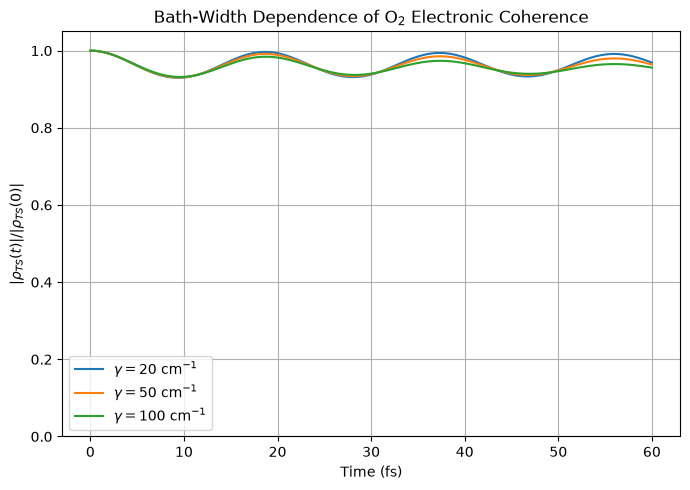

In [27]:
plt.figure(figsize=(7, 5))

for width_value, result in width_results.items():
    plt.plot(
        result["time"],
        result["normalized_coherence"],
        label=rf"$\gamma={width_value:g}$ cm$^{{-1}}$",
    )

plt.xlabel("Time (fs)")
plt.ylabel(r"$|\rho_{TS}(t)|/|\rho_{TS}(0)|$")
plt.title("Bath-Width Dependence of O$_2$ Electronic Coherence")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
def summarize_coherence(result):
    t = result["time"]
    c = result["normalized_coherence"]

    target = np.exp(-1)
    crossing = np.where(c <= target)[0]

    coherence_time = np.nan
    if len(crossing) > 0:
        coherence_time = t[crossing[0]]

    return {
        "final_coherence": c[-1],
        "minimum_coherence": np.min(c),
        "coherence_time_fs": coherence_time,
    }

In [29]:
temperature_summary = []

for temperature_value, result in temperature_results.items():
    summary = summarize_coherence(result)

    temperature_summary.append({
        "temperature_K": temperature_value,
        **summary,
    })

temperature_summary_df = pd.DataFrame(temperature_summary)
temperature_summary_df

,temperature_K,final_coherence,minimum_coherence,coherence_time_fs
0,77.0,0.959110,0.929529,NaN
1,150.0,0.964942,0.930205,NaN
2,300.0,0.963891,0.930465,NaN


In [30]:
coupling_summary = []

for factor, result in coupling_results.items():
    summary = summarize_coherence(result)

    coupling_summary.append({
        "coupling_factor": factor,
        "lambda_cm-1": factor * reorganization_energy_cm1,
        **summary,
    })

coupling_summary_df = pd.DataFrame(coupling_summary)
coupling_summary_df

,coupling_factor,lambda_cm-1,final_coherence,minimum_coherence,coherence_time_fs
0,0.25,16.439965,0.992423,0.982360,NaN
1,1.00,65.759859,0.963891,0.930465,NaN
2,2.00,131.519717,0.926191,0.865448,NaN


In [31]:
width_summary = []

for width_value, result in width_results.items():
    summary = summarize_coherence(result)

    width_summary.append({
        "bath_width_cm-1": width_value,
        **summary,
    })

width_summary_df = pd.DataFrame(width_summary)
width_summary_df

,bath_width_cm-1,final_coherence,minimum_coherence,coherence_time_fs
0,20.0,0.968987,0.929674,NaN
1,50.0,0.963891,0.930465,NaN
2,100.0,0.955911,0.931754,NaN


In [32]:
results_dir = Path("../data/summary")
results_dir.mkdir(parents=True, exist_ok=True)

temperature_summary_df.to_csv(
    results_dir / "temperature_summary.csv",
    index=False,
)

coupling_summary_df.to_csv(
    results_dir / "coupling_summary.csv",
    index=False,
)

width_summary_df.to_csv(
    results_dir / "bath_width_summary.csv",
    index=False,
)